In [1]:
# pytorh相关的工具包
import torch
import torchvision
import torchvision.transforms as transforms
# from torchvision.io import read_image
# 读取图像的工具包
from PIL import Image
# 绘图
import matplotlib.pyplot as plt

# 数据加载

In [2]:
img = Image.open('img2.jpg')

In [3]:
img.size

(994, 734)

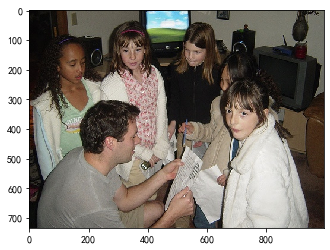

In [4]:
plt.imshow(img)

In [5]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Resize((800,800))])

In [6]:
img = transform(img)

In [7]:
img.shape

torch.Size([3, 800, 800])

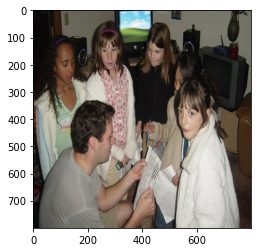

In [8]:
plt.imshow(img.permute(1,2,0))

# 模型加载

In [5]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\14767/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


In [6]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

# 模型预测

In [11]:
# coco数据集的class，共90个类别：人，自行车，火车，。。。
coco_names = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

In [12]:
pred = model([img])

/Users/mac/opt/anaconda3/envs/dltorch/lib/python3.7/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [13]:
pred

[{'boxes': tensor([[ 31.7399, 328.4528, 460.8738, 793.4400],
          [  5.6514,  88.6435, 216.9703, 635.1252],
          [367.4497, 225.4498, 762.0249, 789.4284],
          [607.8991, 152.3864, 795.5750, 372.0394],
          [183.5409,  34.5758, 396.0948, 661.7242],
          [364.9885,  43.9209, 525.7601, 586.4974],
          [ 13.4759, 211.1637, 290.4755, 748.9048],
          [307.3405,   4.9721, 439.2374, 111.8531],
          [383.3587, 180.4190, 578.4739, 772.2529],
          [407.8741, 139.6278, 681.9370, 533.0029],
          [711.5732,   5.5169, 758.7169, 120.2260],
          [479.1790, 144.8082, 689.6121, 400.8835],
          [244.1306,  36.7394, 487.5280, 744.1151],
          [546.8978, 474.4509, 568.8634, 552.9698],
          [742.9993, 314.1062, 798.9455, 607.5062],
          [742.6909, 317.4082, 796.8760, 619.5782],
          [524.8398, 475.1719, 576.5832, 769.7741],
          [509.4732, 142.5110, 623.7419, 301.2690],
          [469.8165, 142.4818, 800.0000, 396.9042],
   

In [14]:
list(pred[0]['labels'].numpy())

[1,
 1,
 1,
 72,
 1,
 1,
 1,
 72,
 1,
 1,
 86,
 1,
 1,
 32,
 63,
 62,
 32,
 1,
 72,
 1,
 32,
 1,
 1,
 63,
 32,
 62,
 32,
 44,
 63,
 72,
 86,
 32,
 1,
 1,
 79,
 85,
 32,
 72]

In [14]:
pred_class = [coco_names[i] for i in list(pred[0]['labels'].numpy())]

In [15]:
pred_class

['person',
 'person',
 'person',
 'tv',
 'person',
 'person',
 'person',
 'tv',
 'person',
 'person',
 'vase',
 'person',
 'person',
 'tie',
 'couch',
 'chair',
 'tie',
 'person',
 'tv',
 'person',
 'tie',
 'person',
 'person',
 'couch',
 'tie',
 'chair',
 'tie',
 'bottle',
 'couch',
 'tv',
 'vase',
 'tie',
 'person',
 'person',
 'oven',
 'clock',
 'tie',
 'tv']

In [16]:
pred[0]['boxes'].detach().numpy()

array([[ 31.739914 , 328.45282  , 460.87378  , 793.44     ],
       [  5.65139  ,  88.64346  , 216.97028  , 635.12524  ],
       [367.4497   , 225.44983  , 762.0249   , 789.4284   ],
       [607.8991   , 152.38641  , 795.575    , 372.03937  ],
       [183.54091  ,  34.575836 , 396.09485  , 661.72424  ],
       [364.9885   ,  43.92093  , 525.76013  , 586.49744  ],
       [ 13.475891 , 211.1637   , 290.47552  , 748.90485  ],
       [307.3405   ,   4.9721336, 439.23743  , 111.85315  ],
       [383.3587   , 180.41904  , 578.47394  , 772.2529   ],
       [407.8741   , 139.62776  , 681.937    , 533.0029   ],
       [711.57324  ,   5.516918 , 758.7169   , 120.22604  ],
       [479.17905  , 144.80818  , 689.61206  , 400.88348  ],
       [244.13058  ,  36.73944  , 487.52798  , 744.1151   ],
       [546.8978   , 474.45093  , 568.8634   , 552.96985  ],
       [742.9993   , 314.10623  , 798.9455   , 607.5062   ],
       [742.6909   , 317.40823  , 796.876    , 619.57825  ],
       [524.8398   , 475

In [17]:
pred_box = [[(box[0],box[1]),(box[2],box[3])] for box in list(pred[0]['boxes'].detach().numpy())]

In [18]:
pred_box

[[(31.739914, 328.45282), (460.87378, 793.44)],
 [(5.65139, 88.64346), (216.97028, 635.12524)],
 [(367.4497, 225.44983), (762.0249, 789.4284)],
 [(607.8991, 152.38641), (795.575, 372.03937)],
 [(183.54091, 34.575836), (396.09485, 661.72424)],
 [(364.9885, 43.92093), (525.76013, 586.49744)],
 [(13.475891, 211.1637), (290.47552, 748.90485)],
 [(307.3405, 4.9721336), (439.23743, 111.85315)],
 [(383.3587, 180.41904), (578.47394, 772.2529)],
 [(407.8741, 139.62776), (681.937, 533.0029)],
 [(711.57324, 5.516918), (758.7169, 120.22604)],
 [(479.17905, 144.80818), (689.61206, 400.88348)],
 [(244.13058, 36.73944), (487.52798, 744.1151)],
 [(546.8978, 474.45093), (568.8634, 552.96985)],
 [(742.9993, 314.10623), (798.9455, 607.5062)],
 [(742.6909, 317.40823), (796.876, 619.57825)],
 [(524.8398, 475.17194), (576.5832, 769.7741)],
 [(509.47318, 142.51099), (623.74194, 301.26895)],
 [(469.81653, 142.48177), (800.0, 396.90424)],
 [(178.56403, 253.69843), (659.58, 785.6712)],
 [(365.37836, 474.17865),

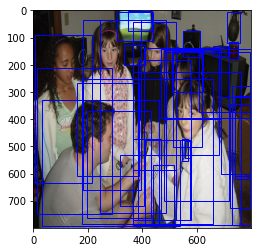

In [19]:
# 图像读取
img = Image.open('img2.jpg').resize((800,800))
# 图像展示
fig = plt.imshow(img)
# 将框绘制在图像上
for index, boxes in enumerate(pred_box):
    fig.axes.add_patch(plt.Rectangle(
    xy=(boxes[0]), width=boxes[1][0]-boxes[0][0], height=boxes[1][1]-boxes[0][1],
    fill=False, edgecolor="blue", linewidth=1))
plt.show()

In [20]:
the = 0.7

In [21]:
pred_score = list(pred[0]['scores'].detach().numpy())

In [22]:
pred_score

[0.99662447,
 0.98991066,
 0.9894002,
 0.9877265,
 0.9700843,
 0.95981795,
 0.86762965,
 0.79457456,
 0.6888022,
 0.6238965,
 0.5967382,
 0.5821962,
 0.5758556,
 0.53390706,
 0.50142986,
 0.4489189,
 0.3446656,
 0.34053934,
 0.25132728,
 0.20674044,
 0.19888856,
 0.19792202,
 0.18443534,
 0.17802832,
 0.12675783,
 0.08840103,
 0.08642756,
 0.08125935,
 0.07662633,
 0.0747837,
 0.07308833,
 0.07040265,
 0.06783704,
 0.063683495,
 0.0592302,
 0.055396155,
 0.053475436,
 0.053160064]

In [23]:
pred_t = [pred_score.index(score) for score in pred_score if score > the]

In [24]:
index = pred_t[-1]

In [25]:
pred_box = pred_box[:index+1]

In [26]:
pred_box

[[(31.739914, 328.45282), (460.87378, 793.44)],
 [(5.65139, 88.64346), (216.97028, 635.12524)],
 [(367.4497, 225.44983), (762.0249, 789.4284)],
 [(607.8991, 152.38641), (795.575, 372.03937)],
 [(183.54091, 34.575836), (396.09485, 661.72424)],
 [(364.9885, 43.92093), (525.76013, 586.49744)],
 [(13.475891, 211.1637), (290.47552, 748.90485)],
 [(307.3405, 4.9721336), (439.23743, 111.85315)]]

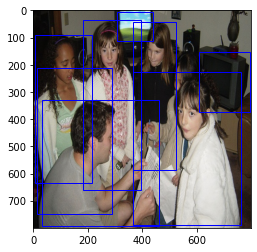

In [27]:
# 图像读取
img = Image.open('img2.jpg').resize((800,800))
# 图像展示
fig = plt.imshow(img)
# 将框绘制在图像上
for index, boxes in enumerate(pred_box):
    fig.axes.add_patch(plt.Rectangle(
    xy=(boxes[0]), width=boxes[1][0]-boxes[0][0], height=boxes[1][1]-boxes[0][1],
    fill=False, edgecolor="blue", linewidth=1))
plt.show()

In [28]:
pred_class[:index+1]

['person', 'person', 'person', 'tv', 'person', 'person', 'person', 'tv']

# 模型结构详解

## backbone

In [30]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Resize((800,800))])
img = transform(img)
img.shape

torch.Size([3, 800, 800])

In [31]:
imgs,targets= model.transform([img],targets=None)

In [32]:
imgs

In [33]:
feature_body= model.backbone.body(imgs.tensors)

In [34]:
C2,C3,C4,C5 = feature_body.values()

In [35]:
C2.size()

torch.Size([1, 256, 200, 200])

In [36]:
C3.size()

torch.Size([1, 512, 100, 100])

In [37]:
C4.size()

torch.Size([1, 1024, 50, 50])

In [38]:
C5.size()

torch.Size([1, 2048, 25, 25])

In [39]:
feature_fpn=model.backbone.fpn(feature_body)

In [40]:
P2,P3,P4,P5,P6=feature_fpn.values()

In [41]:
P2.size()

torch.Size([1, 256, 200, 200])

In [42]:
P3.size()

torch.Size([1, 256, 100, 100])

In [43]:
P4.size()

torch.Size([1, 256, 50, 50])

In [44]:
P5.size()

torch.Size([1, 256, 25, 25])

In [45]:
P6.size()

torch.Size([1, 256, 13, 13])

## RPN

In [46]:
anchors = model.rpn.anchor_generator(imgs,[P2,P3,P4,P5,P6])

In [47]:
anchors

[tensor([[ -23.,  -11.,   23.,   11.],
         [ -16.,  -16.,   16.,   16.],
         [ -11.,  -23.,   11.,   23.],
         ...,
         [ 370.,  551., 1094.,  913.],
         [ 476.,  476.,  988.,  988.],
         [ 551.,  370.,  913., 1094.]])]

In [48]:
anchors[0].size()

torch.Size([159882, 4])

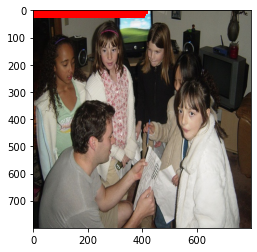

In [49]:
# 将生成的anchor绘制在图像上
img_anchor = Image.open('img2.jpg').resize((800,800))
# 绘制图像
fig = plt.imshow(img_anchor)
# 将框绘制在图像上
for index, boxes in enumerate(anchors[0]):
    if index <300:
        fig.axes.add_patch(plt.Rectangle(
            xy=(boxes[0],boxes[1]), width=boxes[2]-boxes[0], height=boxes[3]-boxes[1],
            fill=False, edgecolor="red", linewidth=1))
plt.show()

In [50]:
cls_logits = model.rpn.head.cls_logits(P3)

In [51]:
cls_logits.size()

torch.Size([1, 3, 100, 100])

In [52]:
bbox_pred = model.rpn.head.bbox_pred(P4)

In [53]:
bbox_pred.size()

torch.Size([1, 12, 50, 50])

In [54]:
proposal = model.rpn(imgs,feature_fpn)

In [58]:
proposal

([tensor([[162.3166,  82.6454, 390.0235, 638.2616],
          [  0.0000,  45.9522, 237.6339, 632.3745],
          [170.6081,  36.5363, 371.3253, 548.1898],
          ...,
          [373.4832, 426.8497, 396.0713, 497.3481],
          [317.5831,   7.1501, 417.4209,  70.2656],
          [395.1561, 506.0393, 427.8982, 546.8923]])],
 {})

In [55]:
proposal[0][0].size()

torch.Size([1000, 4])

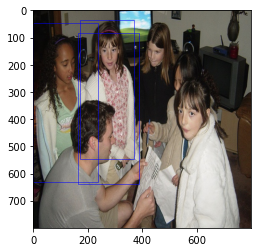

In [56]:
# 候选区域的绘制
img = Image.open('img2.jpg').resize((800,800))
# 显示图像
fig = plt.imshow(img)
# 将候选区域显示在图像上
for index, boxes in enumerate(proposal[0][0]):
    if index <3:
        fig.axes.add_patch(plt.Rectangle(
        xy=(boxes[0],boxes[1]), width=boxes[2]-boxes[0], height=boxes[3]-boxes[1],
        fill=False, edgecolor="blue", linewidth=0.5))
plt.show()

In [59]:
pool_region_list= model.roi_heads.box_roi_pool(feature_fpn,proposal[0],imgs.image_sizes)

In [60]:
pool_region_list.size()

torch.Size([1000, 256, 7, 7])

In [61]:
detection = model.roi_heads(feature_fpn,proposal[0],imgs.image_sizes)

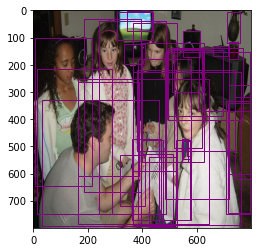

In [62]:
detection_boxes = detection[0][0]['boxes'].detach().numpy()
img = Image.open('img2.jpg').resize((800,800))
# 显示图像
fig = plt.imshow(img)
# 将检测结果绘制在图像上
for index, boxes in enumerate(detection_boxes):
    fig.axes.add_patch(plt.Rectangle(
    xy=(boxes[0],boxes[1]), width=boxes[2]-boxes[0], height=boxes[3]-boxes[1],
    fill=False, edgecolor="purple", linewidth=1))
plt.show()

# 模型训练

## 数据加载

In [63]:
from voc_data_util import VocDataset,VOC_BBOX_LABEL_NAMES

In [64]:
dataset = VocDataset(
    root='datasets/VOCdevkit/VOC2007/',
    transforms=VocDataset.get_transform())

In [65]:
img,targets = dataset[3]

In [66]:
img.size()

torch.Size([3, 800, 800])

In [67]:
import numpy as np
img = img.permute(1,2,0).numpy().astype(np.uint8)

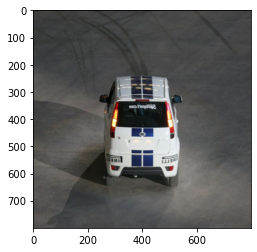

In [68]:
plt.imshow(img)

In [69]:
targets

{'boxes': tensor([[238.4000, 233.0330, 550.4000, 648.6486]], dtype=torch.float64),
 'labels': tensor([7]),
 'image_id': tensor([3]),
 'area': tensor([33735.]),
 'iscrowd': tensor([0])}

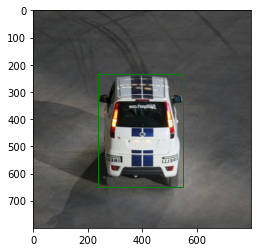

In [70]:
fig = plt.imshow(img)
# 将标注信息绘制在图像上
for index, boxes in enumerate(targets['boxes'].numpy()):
    fig.axes.add_patch(
        plt.Rectangle(xy=(boxes[0], boxes[1]),
                      width=boxes[2] - boxes[0],
                      height=boxes[3] - boxes[1],
                      fill=False,
                      edgecolor="green",
                      linewidth=1))
plt.show()

## 模型加载

In [71]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    pretrained=False, num_classes=21, pretrained_backbone=True)

In [72]:
model.train()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

## RPN正负样本

In [73]:
rpn_label_matchs,rpn_target_deltas= model.rpn.assign_targets_to_anchors(anchors,[targets])

In [74]:
rpn_label_matchs

[tensor([0., 0., 0.,  ..., 0., 0., 0.])]

In [75]:
rpn_target_deltas

[tensor([[238.4000, 233.0330, 550.4000, 648.6486],
         [238.4000, 233.0330, 550.4000, 648.6486],
         [238.4000, 233.0330, 550.4000, 648.6486],
         ...,
         [238.4000, 233.0330, 550.4000, 648.6486],
         [238.4000, 233.0330, 550.4000, 648.6486],
         [238.4000, 233.0330, 550.4000, 648.6486]], dtype=torch.float64)]

In [76]:
positive_anchor_id= torch.where(torch.eq(rpn_label_matchs[0],1))[0].numpy()

In [77]:
positive_anchor_id.shape

(8,)

In [78]:
anchors[0].size()

torch.Size([159882, 4])

158510
158513
158516
158519
158585
158588
158591
158594


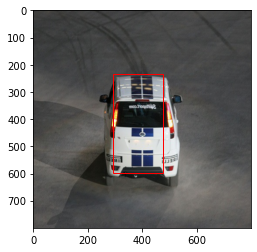

In [79]:
fig = plt.imshow(img)
# 遍历所有的正样本的anchor，绘制在图像上
for idx in positive_anchor_id:
    print(idx)
    if idx == 158513:
        boxes = anchors[0][idx]
        fig.axes.add_patch(plt.Rectangle(
        xy=(boxes[0],boxes[1]), width=boxes[2]-boxes[0], height=boxes[3]-boxes[1],
        fill=False, edgecolor="red", linewidth=1))
plt.show()

In [80]:
negative_anchor_id= torch.where(torch.eq(rpn_label_matchs[0],-1))[0].numpy()

In [81]:
negative_anchor_id.shape

(249,)

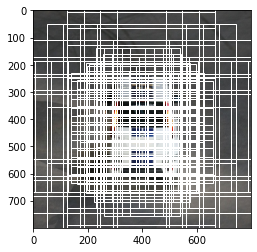

In [82]:
fig = plt.imshow(img)
# 遍历所有的正样本的anchor，绘制在图像上
for idx in negative_anchor_id:
   # print(idx)
    # 负样本的anchor
    boxes = anchors[0][idx]
    # 取余20为0的负样本进行展示
    fig.axes.add_patch(
        plt.Rectangle(xy=(boxes[0], boxes[1]),
                      width=boxes[2] - boxes[0],
                      height=boxes[3] - boxes[1],
                      fill=False,
                      edgecolor="white",
                      linewidth=1))
plt.show()

In [83]:
regression_targets = model.rpn.box_coder.encode(rpn_target_deltas,anchors)

In [84]:
regression_targets[0].size()

torch.Size([159882, 4])

In [85]:
proposals,matched_idx,labels,regression_targets= model.roi_heads.select_training_samples(proposal[0],[targets])

In [86]:
proposals[0].size()

torch.Size([512, 4])

In [87]:
regression_targets[0].size()

torch.Size([512, 4])

In [88]:
labels

[tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 7, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0

In [89]:
positive_proposal_id=torch.where(torch.gt(labels[0],0))[0].numpy()

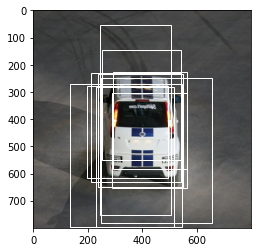

In [90]:
# 绘制部分候选区域的负样本
fig = plt.imshow(img)
# 遍历所有的正样本的候选区域，绘制在图像上
for idx in positive_proposal_id:
    # 正样本的proposals
    boxes = proposals[0][idx]
    # 取余10为0的负样本进行展示
    fig.axes.add_patch(
        plt.Rectangle(xy=(boxes[0], boxes[1]),
                      width=boxes[2] - boxes[0],
                      height=boxes[3] - boxes[1],
                      fill=False,
                      edgecolor="white",
                      linewidth=1))
plt.show()

In [91]:
negitivate_proposal_id = torch.where(torch.eq(labels[0],0))[0].numpy()

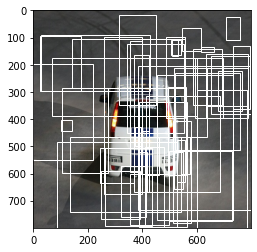

In [92]:
# 绘制部分候选区域的负样本
fig = plt.imshow(img)
# 遍历所有的负样本的候选区域，绘制在图像上
for idx in negitivate_proposal_id:
    # 负样本的proposals
    boxes = proposals[0][idx]
    # 取余10为0的负样本进行展示
    if idx % 10 == 0:
        fig.axes.add_patch(
            plt.Rectangle(xy=(boxes[0], boxes[1]),
                          width=boxes[2] - boxes[0],
                          height=boxes[3] - boxes[1],
                          fill=False,
                          edgecolor="white",
                          linewidth=1))
plt.show()

## 模型训练

In [93]:
from torch.utils.data import DataLoader

In [94]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [95]:
train_data_loader = DataLoader(dataset,batch_size=2,shuffle = True,collate_fn = collate_fn)

In [96]:
for i,data in enumerate(train_data_loader):
    image,targets = data
    print(len(image))
    print(targets)
    break

2
({'boxes': tensor([[224.0000, 140.8000, 425.6000, 522.6666]], dtype=torch.float64), 'labels': tensor([8]), 'image_id': tensor([3183]), 'area': tensor([22554.]), 'iscrowd': tensor([0])}, {'boxes': tensor([[230.4000, 256.0000, 696.0000, 605.8667]], dtype=torch.float64), 'labels': tensor([3]), 'image_id': tensor([2603]), 'area': tensor([47724.]), 'iscrowd': tensor([0])})


In [97]:
# 优化器
params = [p for p in model.parameters() if p.requires_grad]

In [98]:
optimizer = torch.optim.SGD(params,lr= 0.0001,momentum=0.9,weight_decay=0.0001)

In [99]:
# 遍历每个轮次进行训练

# 1.参数的初始化
iters = 0
loss_value = 0
total_train_loss = []
# 2.遍历每个轮次进行训练
for epoch in range(2):
    train_loss = []
    # 3.每个轮次中遍历每个batch
    for images, targets in train_data_loader:
        # 4.把batch数据送入网络中进行预测：损失
        loss_dict = model(images, targets)
        print(loss_dict)
        loss = sum(loss for loss in loss_dict.values())
        loss_value = loss.item()
        train_loss.append(loss_value)
        # 5.进行反向传播：
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch:{epoch},Batch:{iters},loss:{loss_value}")
        iters+=1
        break
    # 6.保存一此列的参数
    epoch_loss = np.mean(train_loss)
    total_train_loss.append(epoch_loss)
    break

{'loss_classifier': tensor(110.5280, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(22.8108, grad_fn=<DivBackward0>), 'loss_objectness': tensor(7.9993, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(7.4245, dtype=torch.float64, grad_fn=<DivBackward0>)}
Epoch:0,Batch:0,loss:148.76265928275987
